In [1]:
import numpy as np
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from aeon.transformations.collection.interval_based import QUANTTransformer
import numpy as np
import polars as pl
from aeon.classification.base import BaseClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
import os
from aeon.transformations.collection.convolution_based import Rocket
from aeon.datasets.tsc_datasets import univariate
from sklearn.base import clone
from aeon.classification.convolution_based import MultiRocketHydraClassifier
from aeon.classification.convolution_based import RocketClassifier
from sklearn.metrics import accuracy_score
from aeon.classification.interval_based import QUANTClassifier
from autotsc import utils, models
from tqdm import tqdm
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.interval_based import QUANTClassifier
from aeon.classification.shapelet_based import RDSTClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier


In [2]:
#from amltk.ensembling.weighted_ensemble_caruana import weighted_ensemble_caruana
#
#X1 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X1 = X1 / X1.sum(axis=1, keepdims=True)
#
#X2 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X2 = X2 / X2.sum(axis=1, keepdims=True)
#
#X3 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X3 = X3 / X3.sum(axis=1, keepdims=True)
#
#model_predictions = {
#    'MR': m.test_pred1,
#    'QUANT': m.test_pred2,
#    'RDST': m.test_pred3,
#    'TEST': X1,
#    'TEST2': X2,
#    'TEST3': X3,
#}
#
#for k, v in model_predictions.items():
#    print(k, v.shape)
#
#def accuracy(y_true, y_pred):
#    # Convert to integers (0,1,2,3) for argmax comparison
#    # but *does not* affect predictions
#    unique = sorted(set(y_true))
#    mapping = {label: i for i, label in enumerate(unique)}
#    y_idx = np.array([mapping[x] for x in y_true])
#
#    y_hat = np.argmax(y_pred, axis=1)
#    return np.mean(y_hat == y_idx)
#
#weights, traj, final_pred = weighted_ensemble_caruana(
#    model_predictions=model_predictions,
#    targets=y_test,
#    size=350,                                  # ensemble size / num of draws
#    metric=accuracy,
#    select=max,
#)
#
#weights

In [3]:
df = pl.read_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet").filter(pl.col('model') != 'mixed-v2').filter(pl.col('model') != 'mixed')
df

/tmp/ipykernel_2803894/1401064196.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  df = pl.read_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet").filter(pl.col('model') != 'mixed-v2').filter(pl.col('model') != 'mixed')


dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""GestureMidAirD2""","""mr-hydra""",300,0.7
"""PLAID""","""quant""",300,0.947858
"""ECGFiveDays""","""rdst""",400,0.997677
"""Wafer""","""quant""",500,1.0
…,…,…,…
"""UWaveGestureLibraryAll""","""quant""",300,0.967895
"""SmallKitchenAppliances""","""quant""",200,0.848
"""PigAirwayPressure""","""quant""",300,0.442308


In [4]:
from aeon.visualisation import plot_critical_difference

In [5]:
v = df.pivot(on='model', values='test_accuracy', index='dataset', aggregate_function='mean').drop_nulls()
methods = df['model'].unique().to_list()
v

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4
str,f64,f64,f64,f64,f64,f64
"""PLAID""",0.941899,0.945624,0.935444,0.955773,0.953445,0.955307
"""Wafer""",0.999676,1.0,1.0,0.999838,0.999838,0.999903
"""CricketY""",0.849231,0.805128,0.835897,0.84359,0.852564,0.851795
"""Beef""",0.766667,0.791667,0.833333,0.773333,0.766667,0.806667
"""CBF""",0.995556,0.995333,0.994444,0.996222,0.995556,0.996222
…,…,…,…,…,…,…
"""InsectEPGSmallTrain""",1.0,1.0,0.991968,1.0,1.0,1.0
"""ItalyPowerDemand""",0.969226,0.9655,0.944606,0.964431,0.968902,0.966958
"""OliveOil""",0.966667,0.933333,0.888889,0.911111,0.9,0.9


(<Figure size 600x250 with 1 Axes>, <Axes: >)

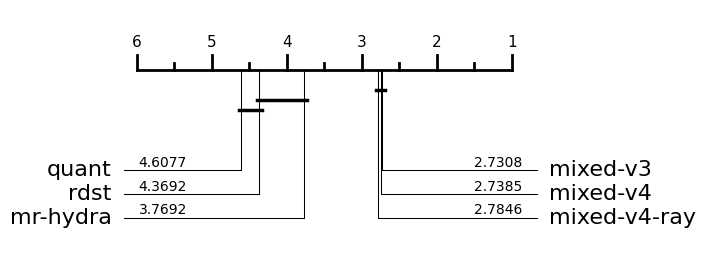

In [6]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [7]:
def dataset_stats():
    import collections
    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append({'dataset': dataset,
                      'n_train': X_train.shape[0],
                      'n_test': X_test.shape[0],
                      'n_classes': len(np.unique(y_train)),
                      'series_length': X_train.shape[2],
                      })
    return pl.DataFrame(stats)

stats = dataset_stats()

HTTPError: HTTP Error 502: Bad Gateway

In [ ]:
joined = v.join(stats, on='dataset').sort('n_train')
joined

In [ ]:
s_small = joined.filter(pl.col('n_train') < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

In [ ]:
s_medium = joined.filter(pl.col('n_train') >= 200).filter(pl.col('n_train') < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

In [ ]:
s_large = joined.filter(pl.col('n_train') >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [ ]:
s_large